# Las megacrecidas que dejaron a Europa bajo el agua en 1342

Un solo año. **62 series fluviales** con crecida grande o extraordinaria, repartidas por todo el continente. En los otros 714 años del registro, la mediana anual es **5**. (Conteo crudo, sin la corrección de sesgo del paper.)

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Kiss et al. (2026) — *Cascading continental-scale floods across Europe in 1342–1343*
**Journal:** Nature · **DOI:** [10.1038/s41586-026-10888-8](https://doi.org/10.1038/s41586-026-10888-8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-12-megainundaciones-europa-1342/notebook.ipynb)

**Video:** [Pendiente]

## De dónde salen datos de hace 700 años

No había estaciones de aforo en el siglo XIV. Lo que hay son crónicas de monasterios, actas municipales, cuentas de reparación de puentes y marcas de agua talladas en los muros de las iglesias. El equipo de Kiss reunió esas menciones y las convirtió en una base de datos: **166 registros** de crecidas entre 1341 y 1343, repartidos en lo que hoy son 15 países.

Cada registro trae una intensidad de 1 a 3 — notable, grande, extraordinaria. Es una escala **ordinal**, asignada por historiadores según lo que dice el texto (¿el agua entró a la iglesia?, ¿se llevó el puente?), no una medición de caudal. Sirve para ordenar, no para promediar como si fueran metros cúbicos.

Y el sesgo que hay que tener presente todo el rato: donde más registros hay es donde mejor sobrevivieron los archivos. Los propios autores lo dicen — la distribución geográfica de los archivos es desigual.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANIO_FOCO = 1342             # El año que vamos a poner bajo la lupa
VENTANA_CLIMA = (1200, 1500) # Periodo de referencia para los índices climáticos
FUENTE = 'Fuente: Kiss et al. (2026), Nature | Datos: Supplementary Data 1, 3, 4 y 5/6'
COLOR_DATOS = '#2563EB'      # Azul CaM — datos principales
COLOR_ALERTA = '#DC2626'     # Rojo — el año que destacamos
COLOR_SECUNDARIO = '#059669' # Emerald — segunda serie
COLOR_REFERENCIA = '#D97706' # Amber — umbrales y medianas
COLOR_CONTEXTO = '#BBBBBB'   # Gris — fondo histórico

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo visual del canal
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga ──
crecidas = pd.read_csv('datos/inundaciones_documentadas.csv')
frecuencia = pd.read_csv('datos/frecuencia_700_anios.csv')
impactos = pd.read_csv('datos/impactos_socioeconomicos.csv')
clima = pd.read_csv('datos/causas_climaticas.csv')

# Nombres de las clases de intensidad (escala ordinal 1-3)
CLASES = {1: 'Notable', 2: 'Grande', 3: 'Extraordinaria'}

print(f'Registros documentales 1341-1343 : {len(crecidas)}')
print(f'  por año                        : '
      f'{crecidas.anio.value_counts().sort_index().to_dict()}')
print(f'  por intensidad                 : '
      f'{ {CLASES[k]: v for k, v in sorted(crecidas.intensidad_3.value_counts().items())} }')
print(f'  países / localidades / aguas    : '
      f'{crecidas.pais_actual.nunique()} / {crecidas.localidad.nunique()} / '
      f'{crecidas.cuerpo_agua.nunique()}')
print(f'  fuentes contemporáneas al hecho: '
      f'{(crecidas.contemporaneidad == 1).sum()} de {len(crecidas)} '
      f'({100 * (crecidas.contemporaneidad == 1).mean():.0f}%)')
print(f'  sin coordenadas (fuera del mapa): {crecidas.lat.isna().sum()}')
print()
print(f'Serie de frecuencia              : {len(frecuencia)} años '
      f'({frecuencia.anio.min()}-{frecuencia.anio.max()})')
print(f'Categorías de impacto            : {len(impactos)} '
      f'({impactos.n_registros.sum()} marcas)')
print(f'Índices climáticos               : {len(clima)} años '
      f'({clima.anio.min()}-{clima.anio.max()})')

Registros documentales 1341-1343 : 166
  por año                        : {1341: 6, 1342: 108, 1343: 52}
  por intensidad                 : {'Notable': 26, 'Grande': 60, 'Extraordinaria': 80}
  países / localidades / aguas    : 15 / 113 / 86
  fuentes contemporáneas al hecho: 138 de 166 (83%)
  sin coordenadas (fuera del mapa): 3

Serie de frecuencia              : 715 años (1300-2014)
Categorías de impacto            : 29 (391 marcas)
Índices climáticos               : 301 años (1200-1500)


Pongamos cada registro donde ocurrió.

Aquí está.

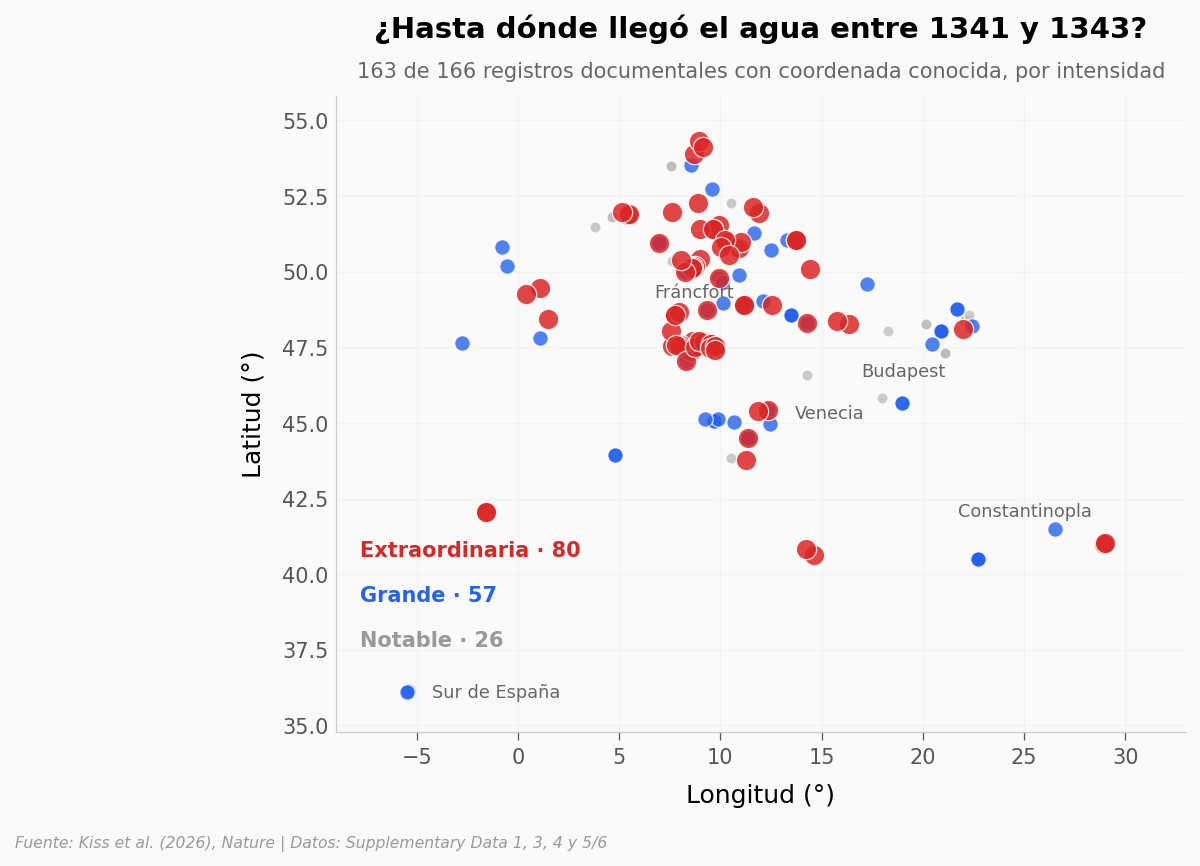

Extensión norte-sur : 36,1°N a 54,3°N (unos 2.020 km)
Extensión este-oeste: 5,5°O a 29,0°E

Registros por país (los 6 con más):
Alemania        76
Italia          17
Hungría         13
Francia         11
Suiza            9
Países Bajos     8


In [2]:
geo = crecidas.dropna(subset=['lat', 'lon']).copy()

fig, ax = plt.subplots(figsize=(13, 5.5))

# Una capa por clase de intensidad: las extraordinarias van encima y más grandes
capas = [
    (1, COLOR_CONTEXTO, 28, 0.75),
    (2, COLOR_DATOS,    55, 0.80),
    (3, COLOR_ALERTA,   95, 0.85),
]
for clase, color, tam, alpha in capas:
    sub = geo[geo.intensidad_3 == clase]
    ax.scatter(sub.lon, sub.lat, s=tam, color=color, alpha=alpha,
               edgecolors='white', linewidths=0.6, zorder=3 + clase)

# Inline labels en vez de legend box
for i, (clase, color, etiqueta) in enumerate([
        (3, COLOR_ALERTA, 'Extraordinaria'),
        (2, COLOR_DATOS, 'Grande'),
        (1, '#999999', 'Notable')]):
    ax.text(-7.8, 40.6 - 1.5 * i,
            f'{etiqueta} · {(geo.intensidad_3 == clase).sum()}',
            fontsize=10, fontweight='bold', color=color)

# Anclas geográficas para orientar al lector
anclas = [
    (8.68, 50.11, 'Fráncfort', 0, -14, 'center'),
    (12.34, 45.44, 'Venecia', 13, -4, 'left'),
    (19.04, 47.50, 'Budapest', 0, -14, 'center'),
    (28.98, 41.01, 'Constantinopla', -6, 13, 'right'),
    (-5.49, 36.12, 'Sur de España', 12, -3, 'left'),
]
for lon, lat, nombre, dx, dy, ha in anclas:
    ax.annotate(nombre, xy=(lon, lat), xytext=(dx, dy),
                textcoords='offset points', fontsize=8.5, color='#666666',
                ha=ha, zorder=10)

ax.set_title('¿Hasta dónde llegó el agua entre 1341 y 1343?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(geo)} de {len(crecidas)} registros documentales con '
                   f'coordenada conocida, por intensidad',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_xlim(-9.0, 33.0)
ax.set_ylim(34.8, 55.8)
ax.set_aspect(1 / np.cos(np.radians(geo.lat.mean())))
ax.grid(alpha=0.25, linewidth=0.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_crecidas.png', dpi=200, bbox_inches='tight')
plt.show()

span_ns = (geo.lat.max() - geo.lat.min()) * 111
print(f'Extensión norte-sur : {geo.lat.min():.1f}°N a {geo.lat.max():.1f}°N '
      f'(unos {span_ns:,.0f} km)'.replace(',', '@').replace('.', ',').replace('@', '.'))
print(f'Extensión este-oeste: {abs(geo.lon.min()):.1f}°O a {geo.lon.max():.1f}°E'
      .replace('.', ','))
PAISES_ES = {'Germany': 'Alemania', 'Italy': 'Italia', 'Hungary': 'Hungría',
             'France': 'Francia', 'Switzerland': 'Suiza',
             'Netherlands': 'Países Bajos'}
print('\nRegistros por país (los 6 con más):')
print(crecidas.pais_actual.replace(PAISES_ES).value_counts()
      .head(6).rename_axis(None).to_string(header=False))

### Lo que llama la atención

No es un río desbordado: son todos a la vez. El registro más al sur está en Andalucía (36,1°N) y el más al norte en la costa frisona del mar del Norte (54,3°N) — unos **2.020 km** de distancia. Y hacia el este llega hasta Constantinopla. Eso ocurrió en cuestión de meses, no de décadas.

Casi la mitad de los registros —**80 de 166**— son de la clase más alta. Ese número hay que leerlo con cuidado en las dos direcciones: por un lado confirma que lo documentado fue grave; por otro, un cronista medieval no anotaba la crecida rutinaria de marzo, anotaba la que se llevó el puente. La base hereda ese filtro.

Alemania aporta **76 de los 166** registros. Eso no significa que ahí lloviera más: significa que sus archivos municipales y monásticos llegaron mejor hasta hoy. Es la advertencia más importante de todo el notebook, y aplica a cada mapa que se haga con fuentes documentales.

El pico es de verano: **70 de 166** registros están fechados en verano, y julio (34) y agosto (33) se lo reparten casi entero — en junio no hay ninguno. En julio de 1342 está la crecida de la Magdalena, la que hasta ahora se tenía como la mayor del último milenio en Europa Central.

## ¿Y esto es mucho?

Un mapa lleno de puntos impresiona, pero no dice nada por sí solo hasta que lo comparamos. Los autores compilaron también el conteo anual de crecidas desde 1300 hasta 2014, agregando 402 series fluviales europeas. Son **715 años** de contexto.

Un aviso antes de mirar: lo que vamos a graficar es el conteo **crudo**. El paper trabaja con una versión corregida por sesgo, que compensa los años con pocos archivos supervivientes. Los dos números son legítimos y no dan lo mismo — volveremos a esto.

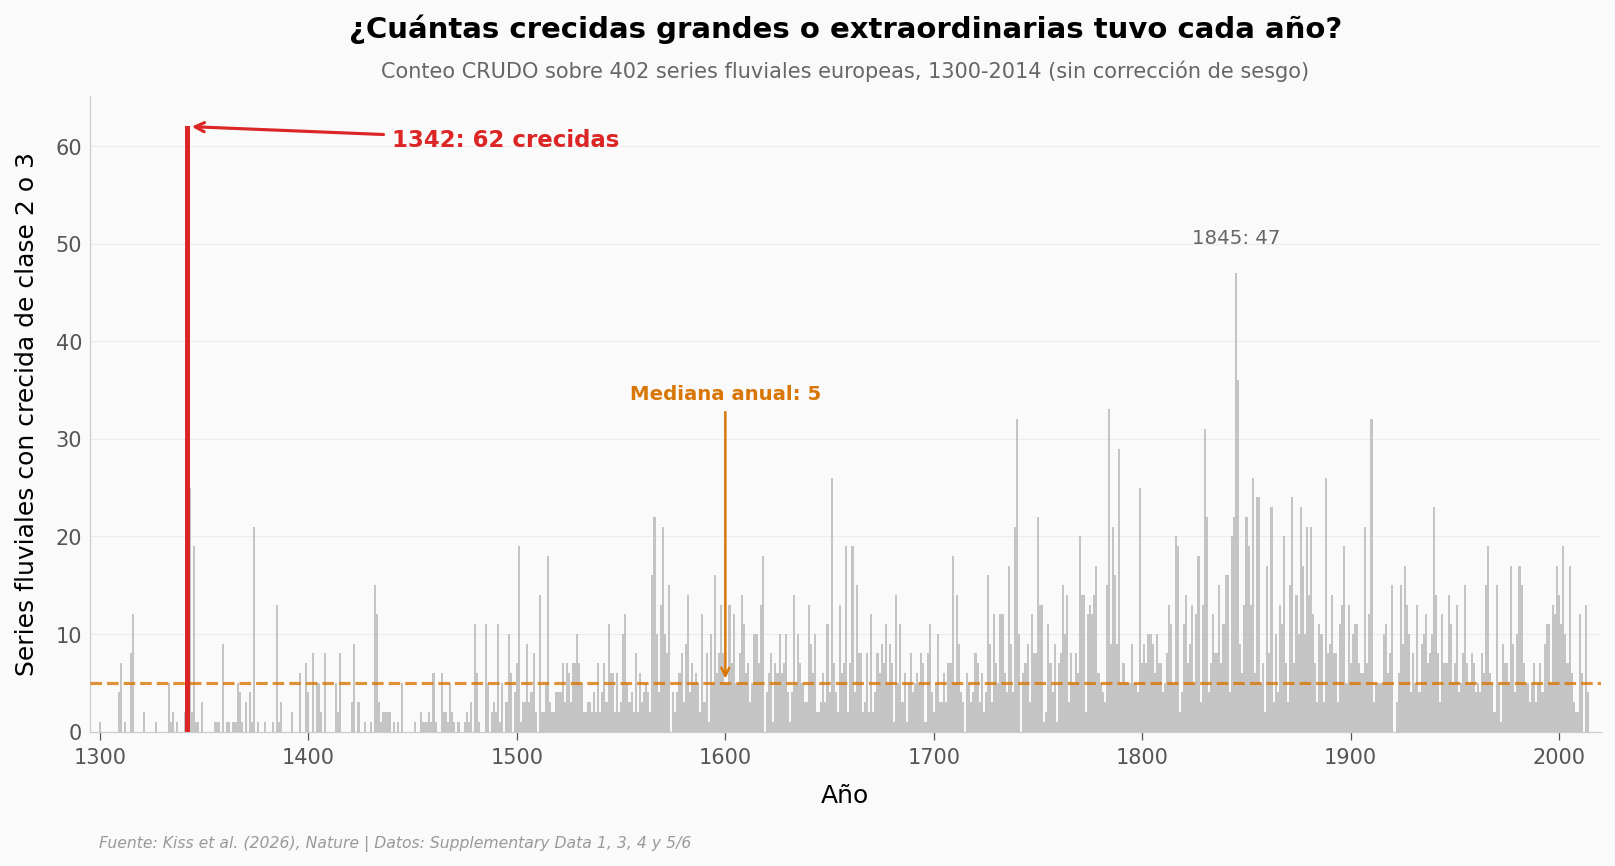

[CRUDO] 1342: 62 crecidas clase 2+3 -> puesto #1 de 715 años
[CRUDO] 1343: 25 crecidas clase 2+3 -> puesto #12
[CRUDO] Contando solo la clase 3 (extraordinaria): 1342 -> #1, 1343 -> #4

Mediana anual : 5 (IQR 2-10, percentil 95: 19)
Asimetría     : 2.13 · curtosis 9.34 -> distribución muy sesgada a la derecha
1342 frente a la mediana : 12.4 veces
1342 frente a 1845 (2.º)   : 1.32 veces
Las dos décadas previas (1320-1341): media 0.6 al año, máximo 5


In [3]:
serie = frecuencia.set_index('anio').clase_2y3

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.bar(serie.index, serie.values, width=1.0, color=COLOR_CONTEXTO,
       alpha=0.85, zorder=3)
foco = serie.loc[ANIO_FOCO]
ax.bar([ANIO_FOCO], [foco], width=2.5, color=COLOR_ALERTA, zorder=5)

mediana = serie.median()
ax.axhline(mediana, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.8, zorder=4)

ax.annotate(f'{ANIO_FOCO}: {foco} crecidas',
            xy=(ANIO_FOCO, foco), xytext=(1440, foco - 2),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.annotate(f'Mediana anual: {mediana:.0f}', xy=(1600, mediana),
            xytext=(1600, 34), ha='center', fontsize=9.5, fontweight='bold',
            color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))

segundo_anio = serie.drop(ANIO_FOCO).idxmax()
segundo_val = serie.loc[segundo_anio]
ax.annotate(f'{segundo_anio}: {segundo_val}',
            xy=(segundo_anio, segundo_val), xytext=(0, 14),
            textcoords='offset points', fontsize=9.5, color='#666666',
            ha='center')

ax.set_title('¿Cuántas crecidas grandes o extraordinarias tuvo cada año?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Conteo CRUDO sobre 402 series fluviales europeas, '
                   '1300-2014 (sin corrección de sesgo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año')
ax.set_ylabel('Series fluviales con crecida de clase 2 o 3')
ax.set_xlim(1295, 2020)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/serie_700_anios.png', dpi=200, bbox_inches='tight')
plt.show()

rank = lambda a: int((serie > serie.loc[a]).sum()) + 1
print(f'[CRUDO] {ANIO_FOCO}: {serie.loc[ANIO_FOCO]} crecidas clase 2+3 '
      f'-> puesto #{rank(ANIO_FOCO)} de {len(serie)} años')
print(f'[CRUDO] 1343: {serie.loc[1343]} crecidas clase 2+3 '
      f'-> puesto #{rank(1343)}')
c3 = frecuencia.set_index('anio').clase_3
rank3 = lambda a: int((c3 > c3.loc[a]).sum()) + 1
print(f'[CRUDO] Contando solo la clase 3 (extraordinaria): '
      f'{ANIO_FOCO} -> #{rank3(ANIO_FOCO)}, 1343 -> #{rank3(1343)}')
print()
print(f'Mediana anual : {serie.median():.0f} '
      f'(IQR {serie.quantile(.25):.0f}-{serie.quantile(.75):.0f}, '
      f'percentil 95: {serie.quantile(.95):.0f})')
print(f'Asimetría     : {serie.skew():.2f} · curtosis {serie.kurtosis():.2f} '
      f'-> distribución muy sesgada a la derecha')
print(f'{ANIO_FOCO} frente a la mediana : {serie.loc[ANIO_FOCO] / serie.median():.1f} veces')
print(f'{ANIO_FOCO} frente a {segundo_anio} (2.º)   : '
      f'{serie.loc[ANIO_FOCO] / segundo_val:.2f} veces')
print(f'Las dos décadas previas (1320-1341): media '
      f'{serie.loc[1320:1341].mean():.1f} al año, máximo {serie.loc[1320:1341].max()}')

## Qué se llevó el agua

Las mismas crónicas que registran la crecida registran lo que pasó después. El equipo clasificó **391 marcas de impacto** en 29 categorías, sobre 178 registros documentales.

Aquí la escala de severidad también va de 1 a 5 y también es ordinal: la asigna un historiador leyendo el texto. La media por categoría describe, no mide.

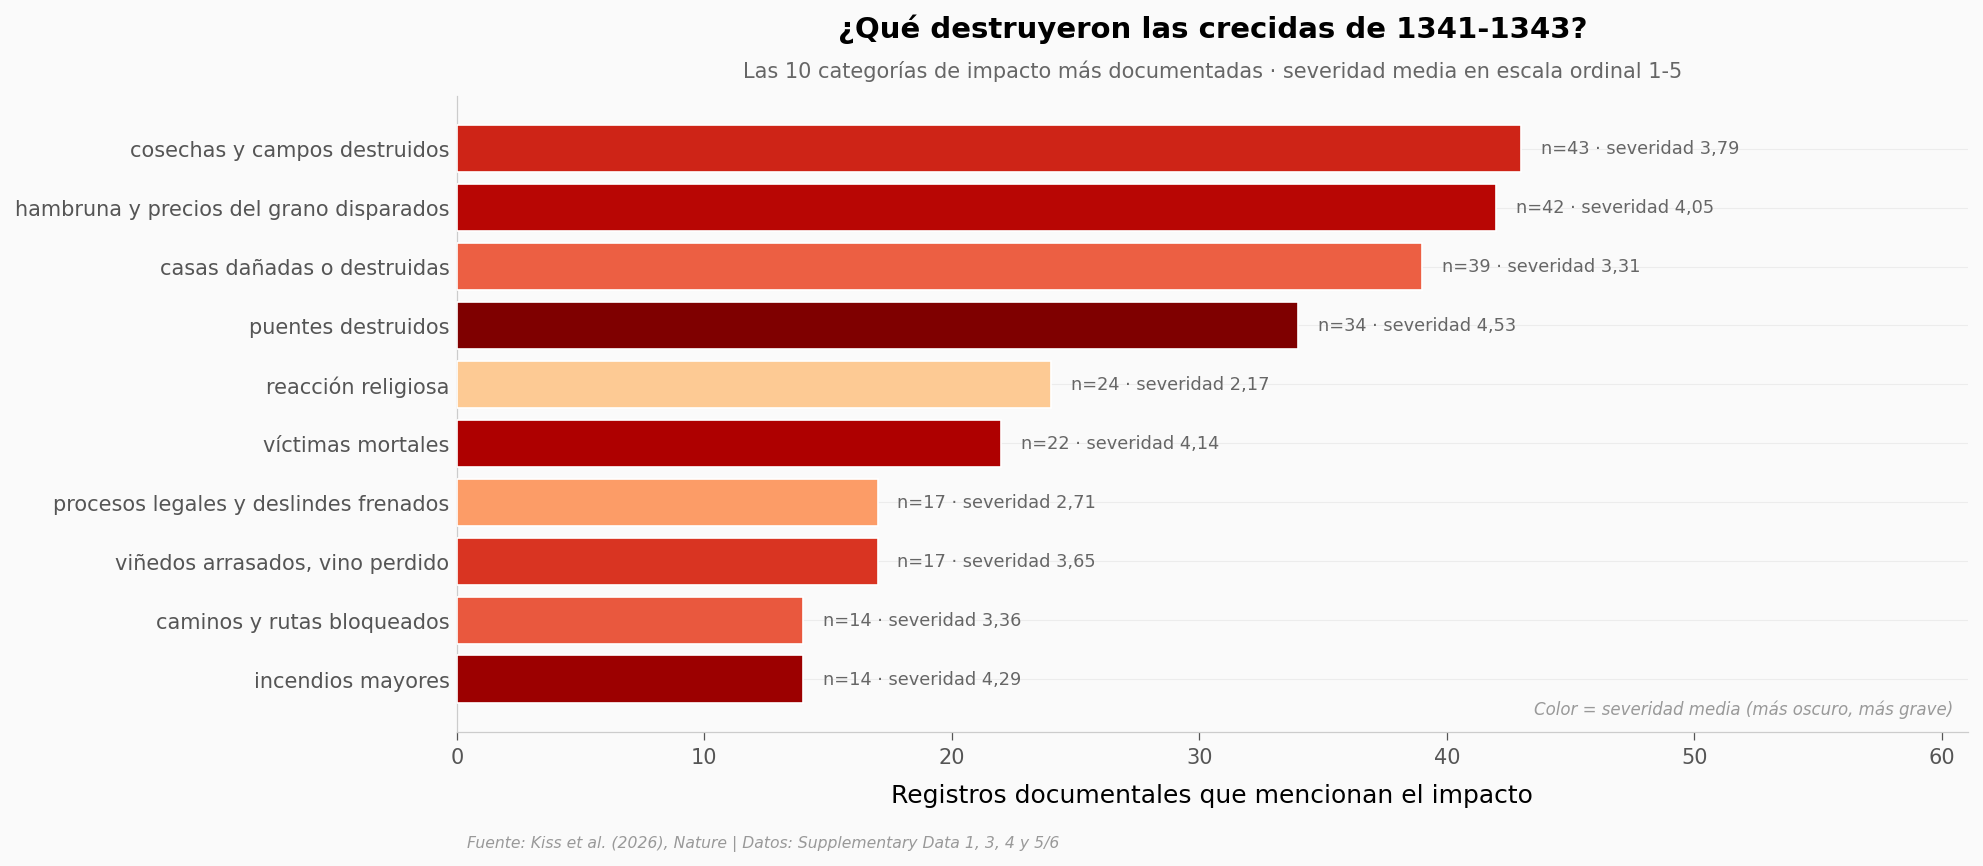

Impactos con la severidad media más alta (con su n):
                  categoria_es  n_registros  severidad_media
              islas sumergidas            3             5.00
  estanques y pesquerías rotos            2             5.00
marcas de crecida y memoriales            1             5.00
murallas dañadas o desbordadas           11             4.82
            puentes destruidos           34             4.53

Reparto de las marcas por año: 1341: 7 · 1342: 223 · 1343: 152 (suman 382 de 391)
Las 9 marcas restantes vienen de registros fechados en 1344, fuera de las tres columnas por año: hambruna 4, reacción religiosa 3,
obras de protección 1 y persecución de comunidades judías 1.


In [4]:
top = impactos.nlargest(10, 'n_registros').sort_values('n_registros')

fig, ax = plt.subplots(figsize=(13, 5.5))

# Color por severidad media: cuanto más oscuro, más grave el registro típico
norm = plt.Normalize(top.severidad_media.min(), top.severidad_media.max())
colores = plt.get_cmap('OrRd')(0.30 + 0.70 * norm(top.severidad_media))
barras = ax.barh(top.categoria_es, top.n_registros, color=colores,
                 edgecolor='white', linewidth=0.8, zorder=3)

for barra, sev, n in zip(barras, top.severidad_media, top.n_registros):
    ax.text(n + 0.8, barra.get_y() + barra.get_height() / 2,
            f'n={n} · severidad {sev:.2f}'.replace('.', ','),
            va='center', fontsize=8.5, color='#666666')

ax.set_title('¿Qué destruyeron las crecidas de 1341-1343?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las 10 categorías de impacto más documentadas · '
                   'severidad media en escala ordinal 1-5',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Registros documentales que mencionan el impacto')
ax.set_xlim(0, top.n_registros.max() * 1.42)
ax.text(0.99, 0.02, 'Color = severidad media (más oscuro, más grave)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/impactos.png', dpi=200, bbox_inches='tight')
plt.show()

print('Impactos con la severidad media más alta (con su n):')
print(impactos.nlargest(5, 'severidad_media')[
    ['categoria_es', 'n_registros', 'severidad_media']].to_string(index=False))
print()
reparto = impactos[['n_1341', 'n_1342', 'n_1343']].sum()
sin_anio = impactos.n_registros.sum() - reparto.sum()
print(f'Reparto de las marcas por año: 1341: {reparto.n_1341:.0f} · '
      f'1342: {reparto.n_1342:.0f} · 1343: {reparto.n_1343:.0f} '
      f'(suman {reparto.sum():.0f} de {impactos.n_registros.sum()})')
print(f'Las {sin_anio:.0f} marcas restantes vienen de registros fechados en 1344, '
      f'fuera de las tres columnas por año: hambruna 4, reacción religiosa 3,')
print('obras de protección 1 y persecución de comunidades judías 1.')

## ¿Y por qué justo ese año?

Aquí toca frenar. Los autores proponen una explicación —una serie de erupciones volcánicas junto con un retroceso del hielo ártico de varios años— y la enmarcan como **causa plausible**, no como causa demostrada. En el cuerpo del paper son todavía más explícitos: dicen que con los modelos climáticos disponibles todavía no es posible una explicación causal directa.

Así que no vamos a decir que los volcanes provocaron las inundaciones. Vamos a mirar qué hacían los índices climáticos que el equipo compiló, y a señalar también dónde la historia no encaja tan limpio.

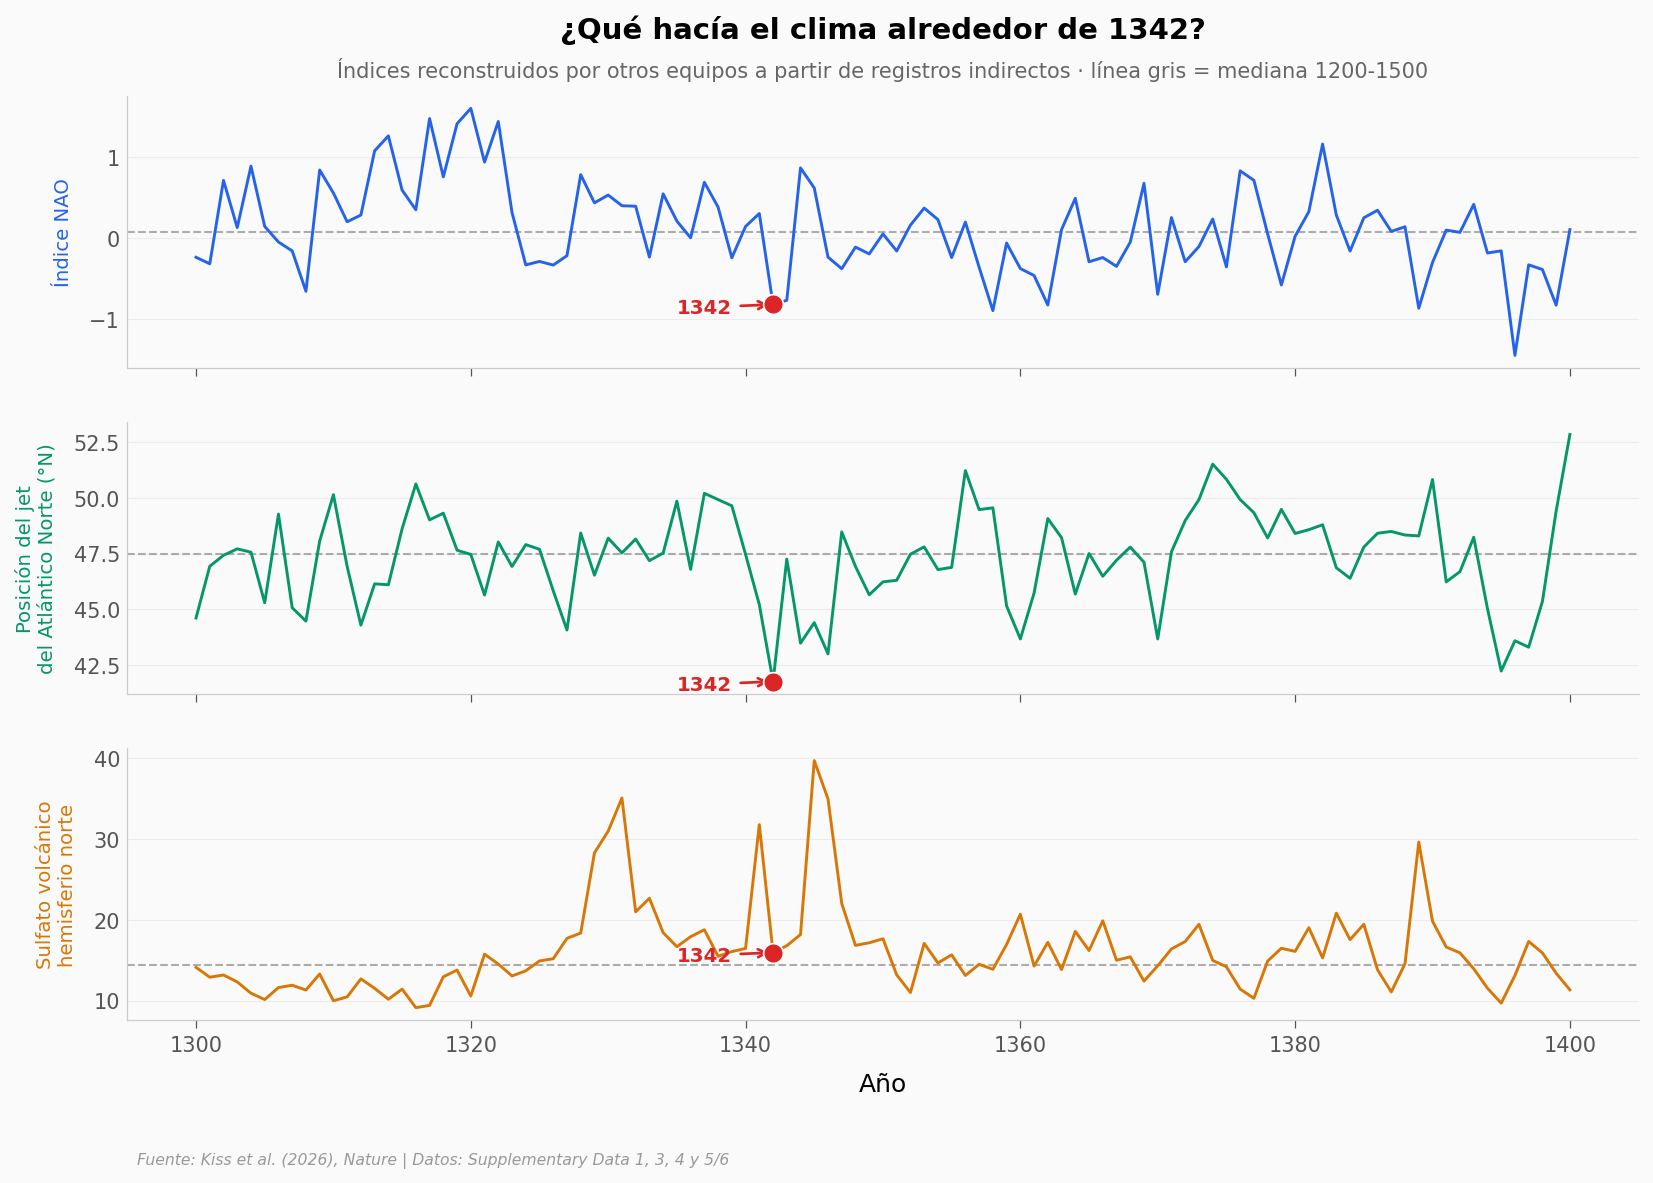

NAO            1341: +0.31 -> 1342: -0.82 (percentil 8 de 1200-1500)
Jet Atl. Norte 1341: 45.2°N -> 1342: 41.8°N (mediana 47.5°N, percentil 2)
Borde norte tropical 1341: 26.7° -> 1342: 23.2°
Hielo ártico derretido en verano 1342: 88% (mediana 57%, percentil 72)

Erupciones registradas en 1340-1341:
 anio  erupciones_islandia  erupciones_extratropicales  erupciones_tropicales
 1340                    2                           3                      6
 1341                    3                           0                      0

Sulfato del hemisferio norte -> 1341: 31.8 · 1342: 15.9 · mediana 1200-1500: 14.4


In [5]:
ini, fin = 1300, 1400
vent = clima[(clima.anio >= ini) & (clima.anio <= fin)]
ref = clima[(clima.anio >= VENTANA_CLIMA[0]) & (clima.anio <= VENTANA_CLIMA[1])]

paneles = [
    ('nao', 'Índice NAO', COLOR_DATOS),
    ('jet_atlantico_norte_grados', 'Posición del jet\ndel Atlántico Norte (°N)', COLOR_SECUNDARIO),
    ('sulfato_hn', 'Sulfato volcánico\nhemisferio norte', COLOR_REFERENCIA),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (col, etiqueta, color) in zip(axes, paneles):
    ax.plot(vent.anio, vent[col], color=color, linewidth=1.4, zorder=3)
    ax.axhline(ref[col].median(), color='#999999', linewidth=1.0,
               linestyle='--', alpha=0.8, zorder=2)
    valor_foco = clima.set_index('anio')[col].loc[ANIO_FOCO]
    ax.scatter([ANIO_FOCO], [valor_foco], s=90, color=COLOR_ALERTA,
               edgecolors='white', linewidths=0.8, zorder=6)
    ax.set_ylabel(etiqueta, fontsize=9.5, color=color)

for ax, (col, _, _) in zip(axes, paneles):
    ax.annotate(f'{ANIO_FOCO}',
                xy=(ANIO_FOCO, clima.set_index('anio')[col].loc[ANIO_FOCO]),
                xytext=(-46, -4), textcoords='offset points',
                fontsize=9.5, fontweight='bold', color=COLOR_ALERTA,
                arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))
axes[2].set_xlabel('Año')
axes[0].set_title('¿Qué hacía el clima alrededor de 1342?',
                  fontsize=14, fontweight='bold', pad=28)
axes[0].text(0.5, 1.07, 'Índices reconstruidos por otros equipos a partir de registros indirectos · '
                        'línea gris = mediana 1200-1500',
             transform=axes[0].transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/clima.png', dpi=200, bbox_inches='tight')
plt.show()

c = clima.set_index('anio')
pct = lambda col, a: 100 * (ref[col] < c[col].loc[a]).mean()
print(f'NAO            1341: {c.nao.loc[1341]:+.2f} -> 1342: {c.nao.loc[1342]:+.2f} '
      f'(percentil {pct("nao", 1342):.0f} de {VENTANA_CLIMA[0]}-{VENTANA_CLIMA[1]})')
print(f'Jet Atl. Norte 1341: {c.jet_atlantico_norte_grados.loc[1341]:.1f}°N -> '
      f'1342: {c.jet_atlantico_norte_grados.loc[1342]:.1f}°N '
      f'(mediana {ref.jet_atlantico_norte_grados.median():.1f}°N, '
      f'percentil {pct("jet_atlantico_norte_grados", 1342):.0f})')
print(f'Borde norte tropical 1341: {c.borde_norte_tropical_grados.loc[1341]:.1f}° -> '
      f'1342: {c.borde_norte_tropical_grados.loc[1342]:.1f}°')
print(f'Hielo ártico derretido en verano 1342: '
      f'{c.hielo_artico_derretido_pct.loc[1342]:.0f}% '
      f'(mediana {ref.hielo_artico_derretido_pct.median():.0f}%, '
      f'percentil {pct("hielo_artico_derretido_pct", 1342):.0f})')
print()
er = clima[clima.anio.isin([1340, 1341])][
    ['anio', 'erupciones_islandia', 'erupciones_extratropicales', 'erupciones_tropicales']]
print('Erupciones registradas en 1340-1341:')
print(er.fillna(0).astype(int).to_string(index=False))
print()
print(f'Sulfato del hemisferio norte -> 1341: {c.sulfato_hn.loc[1341]:.1f} · '
      f'1342: {c.sulfato_hn.loc[1342]:.1f} · '
      f'mediana {VENTANA_CLIMA[0]}-{VENTANA_CLIMA[1]}: {ref.sulfato_hn.median():.1f}')

### Lo que encaja y lo que no

Dos señales sí destacan. El índice NAO —la Oscilación del Atlántico Norte, el vaivén de presiones que decide por dónde entran los temporales— pasa de **+0,31** en 1341 a **−0,82** en 1342: el percentil 8 de todo el periodo 1200-1500. Y el jet del Atlántico Norte —la corriente en chorro, ese río de viento que corre en altura sobre el océano— baja a **41,8°N**, casi seis grados por debajo de su mediana de 47,5°N: el percentil 2. Un jet en esa posición tiende a empujar los temporales atlánticos sobre Europa central y del sur en vez de sobre Escandinavia.

Y ahora lo que no encaja tan bien. Las erupciones que se citan son de **1340 y 1341** — cinco islandesas, tres extratropicales y seis tropicales —, pero el sulfato del hemisferio norte tocó techo en **1341** (31,8) y para 1342 ya había caído a 15,9 — apenas por encima de la mediana del periodo (14,4). El hielo ártico derretido en verano de 1342 estaba en 88%, alto, pero es el percentil 72 del periodo: en 1339 y 1340 fue todavía mayor y no pasó nada parecido.

Es decir: la circulación atmosférica de 1342 sí fue rara de verdad. La cadena que la conecta con los volcanes es la parte que los autores dejan explícitamente abierta — y en la última celda de este notebook se puede comprobar que el jet, por sí solo, no distingue a 1342 de los demás años con el jet igual de bajo.

## ¿Qué tan fuera de norma está 1342?

Ya vimos la serie completa año por año. Falta la pregunta directa: si tomamos los 715 años como una distribución, ¿dónde cae 1342?

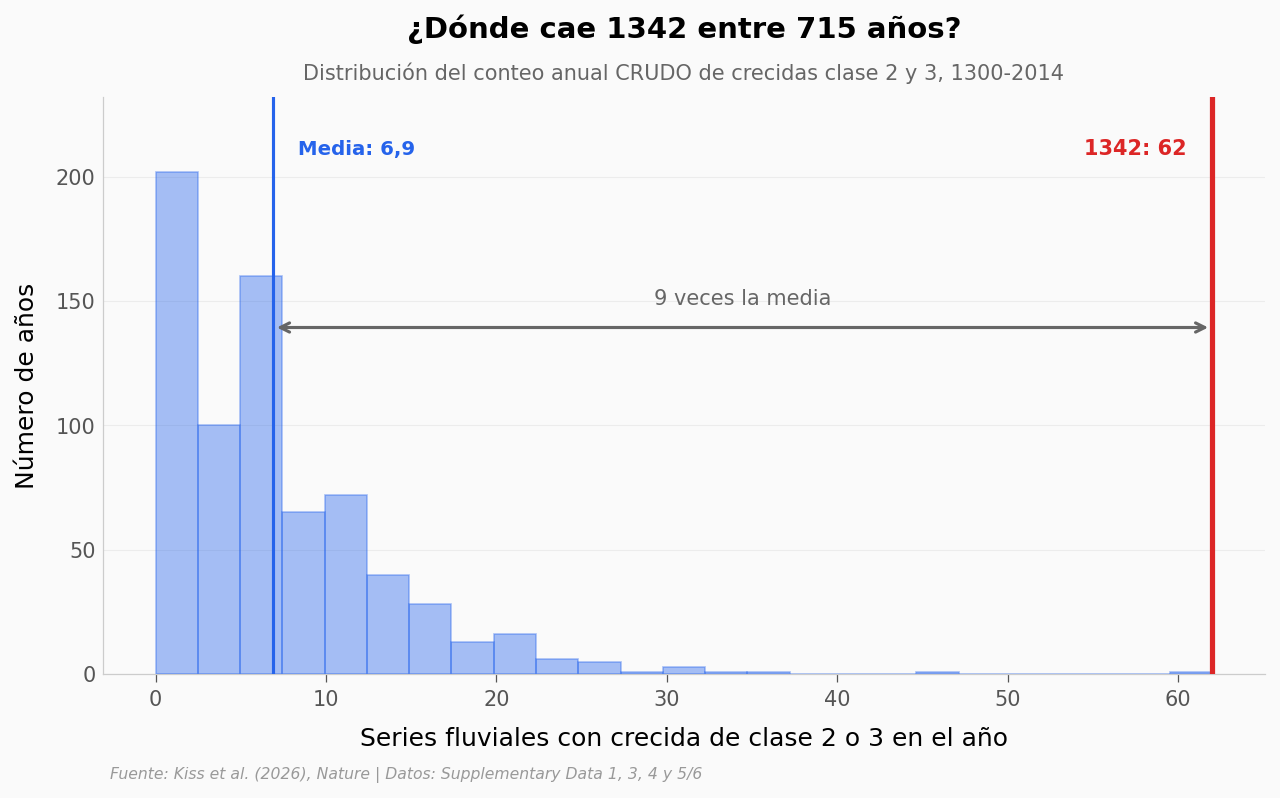

Años con 62 crecidas o más : 1 de 715
Percentil de 1342                : 99.86
Años por encima del percentil 95 (19): 35
1342 + 1343 juntos              : 87 crecidas clase 2+3 [CRUDO]


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(serie.values, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8, zorder=3)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

media = serie.mean()
valor_foco = serie.loc[ANIO_FOCO]
ax.axvline(media, color=COLOR_DATOS, linewidth=1.5, zorder=4)
ax.axvline(valor_foco, color=COLOR_ALERTA, linewidth=2.5, zorder=5)

ax.annotate('', xy=(valor_foco, y_max * 0.6), xytext=(media, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + valor_foco) / 2, y_max * 0.64,
        f'{valor_foco / media:.0f} veces la media'.replace('.', ','),
        fontsize=10, color='#666666', ha='center')
ax.text(media + 1.5, y_max * 0.90, f'Media: {media:.1f}'.replace('.', ','),
        fontsize=9.5, fontweight='bold', color=COLOR_DATOS)
ax.text(valor_foco - 1.5, y_max * 0.90, f'{ANIO_FOCO}: {valor_foco}',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='right')

ax.set_title(f'¿Dónde cae {ANIO_FOCO} entre 715 años?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del conteo anual CRUDO de crecidas '
                   'clase 2 y 3, 1300-2014',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Series fluviales con crecida de clase 2 o 3 en el año')
ax.set_ylabel('Número de años')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_1342.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Años con {valor_foco} crecidas o más : '
      f'{(serie >= valor_foco).sum()} de {len(serie)}')
print(f'Percentil de {ANIO_FOCO}                : '
      f'{100 * (serie < valor_foco).mean():.2f}')
print(f'Años por encima del percentil 95 ({serie.quantile(.95):.0f}): '
      f'{(serie > serie.quantile(.95)).sum()}')
print(f'1342 + 1343 juntos              : '
      f'{serie.loc[1342] + serie.loc[1343]} crecidas clase 2+3 [CRUDO]')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 1342 es el año con más crecidas grandes y extraordinarias del registro | ✅ | Puesto #1 de 715 años con 62 crecidas clase 2+3 en el conteo crudo. El segundo (1845) tiene 47. |
| Las crecidas de 1341-1343 cubrieron gran parte de Europa | ✅ | 163 registros con coordenada, de 36,1°N a 54,3°N y de 5,5°O a 29,0°E, en 15 países actuales. |
| 1343 fue el tercer año del registro | ⚠️ | El paper lo sitúa en el "top ten" usando su serie **corregida por sesgo**. Nuestro conteo **crudo** lo pone en el puesto #12 (o #4 si se cuenta solo la clase 3). Los dos números son correctos: miden cosas distintas. |
| Hubo 16 eventos mayores, 4 con periodo de retorno de 500 a 1.000 años | ➖ | No es computable desde estos CSV. Agrupar 166 registros en 16 eventos lo hicieron los autores a mano, y los propios autores etiquetan sus periodos de retorno como *estimaciones expertas y subjetivas*, no medidas. Lo citamos como dato del paper. |
| Las erupciones volcánicas y el retroceso del hielo ártico causaron la secuencia | ⚠️ | El paper lo enmarca como **causa plausible** y añade que los modelos climáticos disponibles todavía no permiten una explicación causal directa. Nuestros datos muestran una anomalía fuerte de circulación en 1342 (NAO percentil 8, jet percentil 2), pero el sulfato volcánico tocó techo en 1341 y para 1342 ya había caído casi a la mediana del periodo. |
| Alemania fue la región más golpeada | ❌ | Alemania aporta 76 de 166 registros, pero eso refleja **qué archivos sobrevivieron**, no dónde llovió más. Los propios autores señalan la distribución geográfica desigual de los archivos. |
| Las crecidas causaron hambruna y destruyeron infraestructura | ✅ | 391 marcas de impacto en 29 categorías: cosechas (n=43), hambruna y precios del grano (n=42), casas (n=39), puentes (n=34, severidad media 4,53 sobre 5), víctimas mortales (n=22). |

> **Limitaciones**
>
> - **Sesgo de supervivencia documental.** Toda la base depende de qué crónicas llegaron hasta hoy. Un vacío en el mapa puede ser ausencia de crecida o ausencia de archivo — no se distinguen.
> - **Sesgo de registro.** Las crónicas anotan lo excepcional. Que el 48% de los registros sean de clase 3 dice tanto del criterio del cronista como de la crecida.
> - **Escalas ordinales.** Tanto la intensidad (1-3) como la severidad del impacto (1-5) las asignan historiadores leyendo textos. Sus medias son descriptivas; no son caudales ni pérdidas monetarias.
> - **Conteo crudo, no corregido.** La serie de 715 años que graficamos es la versión sin corrección de sesgo. La del paper compensa los años con pocos archivos, y por eso su ranking de 1343 no coincide con el nuestro. El puesto #1 de 1342 sí se sostiene en ambas.
> - **Duración poco documentada.** Solo 9 de los 166 registros traen duración (mediana 9 días, IQR 6-30). Demasiado pocos para generalizar.
> - **Los índices climáticos son proxies de terceros.** NAO, posición del jet y sulfato vienen de reconstrucciones publicadas por otros equipos, con su propia incertidumbre. Los graficamos como contexto, no como medición directa del clima de 1342.

## Ahora tú

1. **¿Se sostiene el puesto #1 de 1342 si solo contamos las crecidas extraordinarias?**
   Pista: repite el ranking con `frecuencia.clase_3` en vez de `clase_2y3`. ¿Cambia el podio?

2. **¿Cómo se ve el mapa si te quedas solo con los registros más fiables?**
   Pista: el dataset trae índices de incertidumbre. Filtra con `crecidas[crecidas.incert_fecha == 1]` y compara cuántos registros quedan por país.

3. **¿Hay otros años con una anomalía de jet parecida a la de 1342, y les siguió una crecida?**
   Pista: busca los años del percentil 5 más bajo de `jet_atlantico_norte_grados` y cruza esos años con `frecuencia`.

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: los años con el jet más al sur, ¿tuvieron más crecidas?
# Ojo: esto es una comparación descriptiva sobre datos observacionales.
# Un año con jet bajo Y muchas crecidas no prueba que uno cause lo otro.

umbral = clima[(clima.anio >= VENTANA_CLIMA[0]) &
               (clima.anio <= VENTANA_CLIMA[1])].jet_atlantico_norte_grados.quantile(0.05)
jet_bajo = clima[(clima.anio >= 1300) & (clima.anio <= VENTANA_CLIMA[1]) &
                 (clima.jet_atlantico_norte_grados <= umbral)]

cruce = jet_bajo.merge(frecuencia[['anio', 'clase_2y3']], on='anio', how='inner')
cruce = cruce[['anio', 'jet_atlantico_norte_grados', 'nao', 'clase_2y3']]

print(f'Umbral del percentil 5 del jet ({VENTANA_CLIMA[0]}-{VENTANA_CLIMA[1]}): '
      f'{umbral:.2f}°N')
print(f'Años con jet igual o por debajo de ese umbral (1300-{VENTANA_CLIMA[1]}): '
      f'{len(cruce)}\n')
print(cruce.sort_values('clase_2y3', ascending=False).to_string(index=False))

resto = frecuencia[(frecuencia.anio >= 1300) & (frecuencia.anio <= VENTANA_CLIMA[1]) &
                   (~frecuencia.anio.isin(cruce.anio))].clase_2y3
print(f'\nMediana de crecidas clase 2+3:')
print(f'  años con jet bajo   : {cruce.clase_2y3.median():.1f} (n={len(cruce)})')
print(f'  resto de {1300}-{VENTANA_CLIMA[1]}   : {resto.median():.1f} (n={len(resto)})')
print(f'\nDe los {len(cruce)} años con el jet más al sur, solo {ANIO_FOCO} destaca: '
      f'los otros {len(cruce) - 1} no superan las {cruce.drop(cruce.clase_2y3.idxmax()).clase_2y3.max()}')
print('crecidas. Un jet bajo, por sí solo, no anticipa una inundación en estos datos.')
print('Es un recordatorio útil: la anomalía de 1342 es real, pero este índice')
print('no la explica por sí solo — que es justo lo que dice el paper.')

Umbral del percentil 5 del jet (1200-1500): 43.15°N
Años con jet igual o por debajo de ese umbral (1300-1500): 12

 anio  jet_atlantico_norte_grados    nao  clase_2y3
 1342                       41.76 -0.818         62
 1500                       41.90  1.134          7
 1413                       43.15  0.801          5
 1489                       41.43 -0.261          3
 1346                       43.00 -0.233          1
 1457                       42.81 -1.974          1
 1407                       43.10 -0.203          0
 1395                       42.23 -0.155          0
 1450                       41.44 -0.445          0
 1418                       41.69 -0.387          0
 1409                       42.86 -0.240          0
 1452                       41.41 -0.898          0

Mediana de crecidas clase 2+3:
  años con jet bajo   : 0.5 (n=12)
  resto de 1300-1500   : 1.0 (n=189)

De los 12 años con el jet más al sur, solo 1342 destaca: los otros 11 no superan las 7
crecidas. Un jet 

---

## Fuentes

**Paper**: [Cascading continental-scale floods across Europe in 1342–1343](https://doi.org/10.1038/s41586-026-10888-8)  
*Nature, 2026-08-12*

**Supplementary Material** (mismo DOI, datos de este notebook):

- [Supplementary Data 1: Flood data and source information and uncertainty evaluation (Kiss et al. 2026)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10888-8/MediaObjects/41586_2026_10888_MOESM2_ESM.xlsx)
- [Supplementary Data 4: European flood datasets of the past 700 years (Kiss et al. 2026)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10888-8/MediaObjects/41586_2026_10888_MOESM5_ESM.xlsx)
- [Supplementary Data 3: Socio-economic impacts of the 1342–1343 floods (Kiss et al. 2026)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10888-8/MediaObjects/41586_2026_10888_MOESM4_ESM.xlsx)
- [Supplementary Data 5/6: Causative factors — volcanic, solar, sea ice and circulation indices (Kiss et al. 2026)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10888-8/MediaObjects/41586_2026_10888_MOESM7_ESM.xlsx)

**Referencias citadas** (origen de los índices climáticos compilados por los autores):

- [Global Volcanism Program — Volcanoes of the World (base de las columnas de erupciones y VEI)](https://volcano.si.edu/)
- [Timing and climate forcing of volcanic eruptions for the past 2,500 years (fuente del sulfato del HN)](https://doi.org/10.1038/nature14565)
- [A model-tested North Atlantic Oscillation reconstruction for the past millennium (fuente de la serie NAO)](https://doi.org/10.1038/nature14518)

*20 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad:** todo el análisis de este notebook corre sobre los CSV de la carpeta `datos/`, derivados del Supplementary Material del paper. El código de extracción y el notebook completo están en el repositorio.

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia del código:** MIT

*El Lab de [Ciencia a Mordiscos](https://cienciaamordiscos.com) — donde se puede revisar lo que decimos en los videos.*